# Ingredients -> Dish: Contrastive QLoRA -  *Triplet-Setup Comparison*

A copy of the pipeline that compares **three different triplet constructions** for the recipe
embedder. In every setup the first item is the **anchor**, the second is the **positive**, the
third is the **negative**:

| Setup | Anchor | Positive | Negative |
|-------|--------|----------|----------|
| **A** | dish name | ingredient list of *that* dish | ingredient list sharing **zero** ingredients |
| **B** | ingredient list | ingredient list sharing **>= 2** ingredients | ingredient list sharing **zero** ingredients |
| **C** | dish name | dish name of a dish sharing **>= 2** ingredients | dish name of a dish sharing **zero** ingredients |

Shared/zero-overlap partner dishes are found once (from `ingredient_similarity_matrix.csv` for the
zero-overlap case and exact shared-ingredient counts for the ">= 2" case) and **reused across all
three setups**, so the setups differ only in how each dish is *represented* (name vs. list).

Training uses the **40-80% ingredient-sampling** technique (same as `Recipe_Modeling.ipynb`). Every
setup is scored on the identical seed-42 retrieval test set with the same metrics. We **display all
setups' metrics** but **cache only the single best-performing model**. Finally, for the best setup we
add a cell that re-trains it on the **entire** ingredient lists (no sampling) and compares.


## Control Center

All toggles are `False` by default (load cached artifacts). Set one to `True` to **re-create** that artifact.

In [1]:
# ============================== CONTROL CENTER ==============================
# All False -> load cached artifacts. Set True to (re)build / retrain that artifact.

# --- Data / test-set artifacts ---
REBUILD_TEST_SET      = False   # seed-42 test queries (must match Recipe_Modeling.ipynb)
REBUILD_BASE_TRIPLES  = False   # (anchor, >=2-shared positive, 0-shared negative) dish-index triples

# --- Triplet-setup experiments (trained with 40-80% ingredient sampling) ---
RETRAIN_SETUPS        = False   # train + evaluate all three setups (A, B, C); caches ONLY the best model
RECOMPUTE_UNTUNED_EMB = False   # embeddings for the un-tuned reference

# --- Best setup: full-recipe-list vs sampled training (bottom cell) ---
RETRAIN_BEST_FULL     = False   # re-train the best setup on ENTIRE ingredient lists (no sampling) & compare

print("Control center loaded.")
_flags = [k for k, v in dict(
    REBUILD_TEST_SET=REBUILD_TEST_SET, REBUILD_BASE_TRIPLES=REBUILD_BASE_TRIPLES,
    RETRAIN_SETUPS=RETRAIN_SETUPS, RECOMPUTE_UNTUNED_EMB=RECOMPUTE_UNTUNED_EMB,
    RETRAIN_BEST_FULL=RETRAIN_BEST_FULL).items() if v]
print("True flags:", (", ".join(_flags) if _flags else "(none - everything loads from cache)"))


Control center loaded.
True flags: (none - everything loads from cache)


## 1. Environment & paths

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Install QLoRA / embedding dependencies (quiet). Safe to re-run.
!pip -q install -U "transformers>=4.51.0" "peft>=0.11.0" "bitsandbytes>=0.43.0" "accelerate>=0.30.0" 2>/dev/null
print("Dependencies ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 16.6 MB/s eta 0:00:00
Dependencies ready.


In [4]:
import os

# --- PATHS (mirror Recipe_Modeling.ipynb; edit here if your folder names differ) ---
HOME_DIR   = '/content/drive/Shareddrives/Computer Vision Final Project'
DATA_DIR   = os.path.join(HOME_DIR, 'Data', 'recipe_dataset', 'data')
MODEL_DIR  = os.path.join(HOME_DIR, 'Modeling')
# All artifacts created by THIS notebook are cached here:
QWEN_DIR   = os.path.join(HOME_DIR, 'Data', 'Qwen_Models')
ART_DIR    = os.path.join(QWEN_DIR, 'artifacts')          # embeddings, test set, triplets
OUT_DIR    = os.path.join(MODEL_DIR, 'output_plots_triplet_setups')  # separate from other notebooks

for d in (QWEN_DIR, ART_DIR, OUT_DIR):
    os.makedirs(d, exist_ok=True)

RECIPES_CSV = os.path.join(DATA_DIR, 'recipes_cleaned.csv')
SIM_CSV     = os.path.join(DATA_DIR, 'ingredient_similarity_matrix.csv')

for p in (RECIPES_CSV, SIM_CSV):
    print(('FOUND ' if os.path.exists(p) else 'MISSING ') + p)


FOUND /content/drive/Shareddrives/Computer Vision Final Project/Data/recipe_dataset/data/recipes_cleaned.csv
FOUND /content/drive/Shareddrives/Computer Vision Final Project/Data/recipe_dataset/data/ingredient_similarity_matrix.csv


In [5]:
import ast, re, time, json, pickle, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 180,
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Helvetica', 'Arial'],
    'axes.titlesize': 14, 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
})

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Torch', torch.__version__, '| device:', DEVICE)
if DEVICE == 'cuda':
    print('GPU   :', torch.cuda.get_device_name(0))

Torch 2.11.0+cu128 | device: cuda
GPU   : Tesla T4


In [6]:
# ============================== CONFIG ==============================
MODEL_NAME = 'Qwen/Qwen3-Embedding-0.6B'

# Evaluation protocol -- identical to Recipe_Modeling.ipynb
N_TEST     = 1000
SEED       = 42
K_VALUES   = [1, 3, 5, 10, 20, 50]

# Embedding
MAX_LEN        = 32     # ingredients / dish names are short
EMB_BATCH      = 256    # batch size for (no-grad) corpus encoding of unique ingredients

# Contrastive QLoRA training
TRIPLETS_PER_RECIPE = 1
TRIPLET_MARGIN      = 0.3       # cosine-distance margin
LORA_R              = 16
LORA_ALPHA          = 32
LORA_DROPOUT        = 0.05
TRAIN_EPOCHS        = 1
TRAIN_BATCH         = 16        # triplets per step
LR                  = 2e-4
GRAD_ACCUM          = 1

# --- TRIPLET-SETUP comparison variant. Namespaced so nothing collides with the other notebooks. ---
VARIANT_TAG = 'tripletsetups'

# Cache file paths
F_TESTSET      = os.path.join(ART_DIR, 'test_set_seed42.pkl')                    # shared seed-42 test set
F_BASE_TRIPLES = os.path.join(ART_DIR, f'base_triples_{VARIANT_TAG}.pkl')        # (anchor,pos,neg) dish indices
F_SETUP_METRICS= os.path.join(ART_DIR, f'setup_metrics_{VARIANT_TAG}.pkl')       # per-setup eval metrics
BEST_ADAPTER   = os.path.join(QWEN_DIR, f'qwen_best_setup_lora_{VARIANT_TAG}')    # ONLY the best model is cached
TMP_ADAPTER_DIR= os.path.join(QWEN_DIR, f'_tmp_setups_{VARIANT_TAG}')             # scratch adapters (deleted after selection)

# Triplet-setup definitions: (anchor_kind, positive_kind, negative_kind). kind in {'text','list'}.
SETUP_KINDS = {
    'A': ('text', 'list', 'list'),   # dish name | own ingredient list | zero-overlap ingredient list
    'B': ('list', 'list', 'list'),   # ingredient list | >=2-shared list | zero-overlap list
    'C': ('text', 'text', 'text'),   # dish name | >=2-shared dish name | zero-overlap dish name
}
SETUP_DESC = {
    'A': 'anchor=dish name | +=own ingredients | -=zero-overlap ingredients',
    'B': 'anchor=ingredients | +=(>=2 shared) ingredients | -=zero-overlap ingredients',
    'C': 'anchor=dish name | +=(>=2 shared) dish name | -=zero-overlap dish name',
}

def emb_cache_path(tag):    # per-model cached embeddings (namespaced to this variant)
    return os.path.join(ART_DIR, f'emb_{VARIANT_TAG}_{tag}.npz')

print('Config set. Model:', MODEL_NAME)

Config set. Model: Qwen/Qwen3-Embedding-0.6B


## 2. Load data

`recipes_cleaned.csv` provides `dish_id`, `dish_name`, and a cleaned `ingredients` list. We parse the ingredient lists and build the same forward index (`recipe_index`) used by the evaluation.

In [7]:
df = pd.read_csv(RECIPES_CSV)
print(f'Loaded {len(df):,} rows | columns: {list(df.columns)}')

def parse_ingredients(val):
    """Parse the `ingredients` column into a clean list of ingredient strings."""
    if isinstance(val, list):
        items = val
    elif pd.isna(val):
        return []
    else:
        s = str(val).strip()
        items = None
        if s.startswith('[') or s.startswith('('):
            try:
                items = list(ast.literal_eval(s))
            except Exception:
                items = None
        if items is None:
            items = [t for t in re.split(r'[,;\n]', s.strip('[]()'))]
    out = []
    for it in items:
        t = str(it).strip().strip('\'"').lower()
        if t:
            out.append(t)
    return out

df['ingredients']    = df['ingredients'].apply(parse_ingredients)
df['ingredient_set'] = df['ingredients'].apply(set)
df['n_ingredients']  = df['ingredients'].apply(len)

before = len(df)
df = df[df['n_ingredients'] > 0].reset_index(drop=True)   # positional index == retrieval id
print(f'Kept {len(df):,} recipes with >=1 ingredient (dropped {before-len(df)}).')
print(f'Avg ingredients/recipe: {df["n_ingredients"].mean():.1f}')
df[['dish_id','dish_name','n_ingredients']].head(3)

Loaded 13,509 rows | columns: ['dish_id', 'dish_name', 'recipe', 'photo_path', 'source', 'instructions', 'ingredient_portions', 'ingredients', 'n_ingredients', 'cuisine', 'rating']
Kept 13,502 recipes with >=1 ingredient (dropped 7).
Avg ingredients/recipe: 10.6


,dish_id,dish_name,n_ingredients
0,KG-000001,Miso-Butter Roast Chicken With Acorn Squash Pa...,21
1,KG-000002,Crispy Salt and Pepper Potatoes,7
2,KG-000003,Thanksgiving Mac and Cheese,10


In [8]:
# Forward index (same structure as Recipe_Modeling.ipynb): positional idx -> recipe info
recipe_index = {}
for idx, row in df.iterrows():
    recipe_index[idx] = {
        'dish_id':       row['dish_id'],
        'dish_name':     row['dish_name'],
        'ingredients':   row['ingredient_set'],
        'n_ingredients': row['n_ingredients'],
    }

# Convenience lookups
dishid_to_name = dict(zip(df['dish_id'], df['dish_name']))
ing_sets       = df['ingredient_set'].tolist()          # positional (sets)
ingredients_col= df['ingredients'].tolist()             # positional (ordered lists)
dish_names     = df['dish_name'].tolist()               # positional
dish_ids       = df['dish_id'].tolist()                 # positional

print(f'Forward index: {len(recipe_index):,} recipes')
print(f'Unique dish_ids: {df["dish_id"].nunique():,}')

Forward index: 13,502 recipes
Unique dish_ids: 13,502


In [9]:
# Load the pre-computed dish x dish ingredient-similarity matrix (keyed on dish_id).
# A value of 0 means the two dishes share ZERO ingredients -> valid negative candidates.
SIM = None
zero_sim_candidates = {}   # dish_id -> list of dish_ids sharing zero ingredients
if os.path.exists(SIM_CSV):
    SIM = pd.read_csv(SIM_CSV, index_col=0)
    SIM.columns = SIM.columns.astype(str)
    SIM.index   = SIM.index.astype(str)
    print(f'Similarity matrix: {SIM.shape[0]} x {SIM.shape[1]} (dish_id-indexed)')
    # Pre-compute zero-overlap candidate lists (restricted to dish_ids present in our df)
    valid_cols = np.array([c for c in SIM.columns])
    col_vals = SIM.values
    col_names = np.array(SIM.columns)
    df_dishid_set = set(dish_ids)
    for did, rowvals in zip(SIM.index, col_vals):
        if did not in df_dishid_set:
            continue
        mask = (rowvals == 0)
        cands = [c for c in col_names[mask] if c != did and c in df_dishid_set]
        if cands:
            zero_sim_candidates[did] = cands
    print(f'Built zero-overlap candidate lists for {len(zero_sim_candidates):,} dishes.')
else:
    print('WARNING: similarity matrix not found - negatives will use the set-based fallback only.')

Similarity matrix: 13509 x 13509 (dish_id-indexed)
Built zero-overlap candidate lists for 13,502 dishes.


## 3. Reproduce the train/test split from `Recipe_Modeling.ipynb`

The evaluation corpus is **all** recipes (the true dish must be retrievable). The **test set** is the identical seed-42 draw of 1,000 recipes, each turned into a query of 40-80% of its ingredients. Training triplets are drawn only from the **remaining** recipes, so no test dish is used as a training anchor.

In [10]:
# --- Reproduce the EXACT seed-42 test-set construction from Recipe_Modeling.ipynb ---
def build_test_set():
    np.random.seed(SEED)
    test_indices = np.random.choice(len(df), size=N_TEST, replace=False)
    query_sets, true_recipe_ids, query_fractions = [], [], []
    for idx in test_indices:
        full_set = df.iloc[idx]['ingredient_set']
        if len(full_set) < 2:
            continue
        frac = np.random.uniform(0.4, 0.8)
        n_sample = max(1, int(len(full_set) * frac))
        sampled = set(np.random.choice(list(full_set), size=n_sample, replace=False))
        query_sets.append(sampled)
        true_recipe_ids.append(int(idx))
        query_fractions.append(n_sample / len(full_set))
    return test_indices, query_sets, true_recipe_ids, query_fractions

if REBUILD_TEST_SET or not os.path.exists(F_TESTSET):
    test_indices, query_sets, true_recipe_ids, query_fractions = build_test_set()
    with open(F_TESTSET, 'wb') as f:
        pickle.dump({'test_indices': test_indices, 'query_sets': query_sets,
                     'true_recipe_ids': true_recipe_ids, 'query_fractions': query_fractions}, f)
    print('Built and cached test set.')
else:
    with open(F_TESTSET, 'rb') as f:
        d = pickle.load(f)
    test_indices, query_sets = d['test_indices'], d['query_sets']
    true_recipe_ids, query_fractions = d['true_recipe_ids'], d['query_fractions']
    print('Loaded cached test set.')

test_id_set  = set(int(i) for i in test_indices)
train_indices = np.array([i for i in range(len(df)) if i not in test_id_set])

print(f'Test queries : {len(query_sets):,}')
print(f'Avg query fraction: {np.mean(query_fractions):.1%} of original ingredients')
print(f'Avg query size    : {np.mean([len(q) for q in query_sets]):.1f} ingredients')
print(f'Train recipes (triplet source): {len(train_indices):,}')

Loaded cached test set.
Test queries : 998
Avg query fraction: 54.0% of original ingredients
Avg query size    : 5.7 ingredients
Train recipes (triplet source): 12,502


## 5. Embedding model utilities

Qwen3-Embedding uses **last-token pooling** to turn a string into a vector. We add a second level of pooling **across ingredients** to produce the recipe embedding: `mean` (default), `max`, or `concat` (embed the whole list as one string -> no ingredient-level pooling).

In [11]:
from transformers import AutoTokenizer, AutoModel, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel, TaskType

def last_token_pool(last_hidden, attention_mask):
    """Embedding = hidden state of the last non-padding token (Qwen3-Embedding convention)."""
    left_padded = bool((attention_mask[:, -1].sum() == attention_mask.shape[0]).item())
    if left_padded:
        return last_hidden[:, -1]
    lengths = attention_mask.sum(dim=1) - 1
    return last_hidden[torch.arange(last_hidden.size(0), device=last_hidden.device), lengths]

def load_base_model(quantized=True):
    tok = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    kwargs = dict(trust_remote_code=True)
    if quantized and DEVICE == 'cuda':
        kwargs['quantization_config'] = BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_quant_type='nf4',
            bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True)
        kwargs['device_map'] = {'': 0}
        kwargs['torch_dtype'] = torch.bfloat16
    else:
        kwargs['torch_dtype'] = torch.float32
    model = AutoModel.from_pretrained(MODEL_NAME, **kwargs)
    if not (quantized and DEVICE == 'cuda'):
        model = model.to(DEVICE)
    return tok, model

def attach_lora(model):
    """Wrap a 4-bit base model with trainable LoRA adapters (QLoRA)."""
    model = prepare_model_for_kbit_training(model)
    cfg = LoraConfig(
        r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT, bias='none',
        target_modules=['q_proj','k_proj','v_proj','o_proj','gate_proj','up_proj','down_proj'],
        task_type=TaskType.FEATURE_EXTRACTION)
    return get_peft_model(model, cfg)

def encode_strings(model, tok, strings, grad=False, max_len=MAX_LEN):
    """Return L2-normalized last-token embeddings for a list of strings, shape [n, d]."""
    enc = tok(list(strings), padding=True, truncation=True, max_length=max_len,
              return_tensors='pt').to(DEVICE)
    ctx = torch.enable_grad() if grad else torch.no_grad()
    with ctx:
        out = model(**enc)
        emb = last_token_pool(out.last_hidden_state, enc['attention_mask'])
        emb = F.normalize(emb.float(), p=2, dim=-1)
    return emb

def pool_segments(emb, seg_lengths, pooling):
    """Pool a stacked [sum(seg), d] tensor into [len(seg), d] by mean or max per segment."""
    out, i = [], 0
    for m in seg_lengths:
        chunk = emb[i:i+m]; i += m
        v = chunk.mean(0) if pooling == 'mean' else chunk.max(0).values
        out.append(v)
    return torch.stack(out)

def embed_recipes_train(model, tok, ing_lists, pooling):
    """Differentiable recipe embeddings for a batch of ingredient lists."""
    if pooling == 'concat':
        strings = [', '.join(lst) for lst in ing_lists]
        return encode_strings(model, tok, strings, grad=True)         # already normalized
    flat, seg = [], []
    for lst in ing_lists:
        seg.append(len(lst)); flat.extend(lst)
    emb = encode_strings(model, tok, flat, grad=True)                  # [sum(seg), d]
    R   = pool_segments(emb, seg, pooling)
    return F.normalize(R, p=2, dim=-1)

print('Embedding utilities defined.')

# ---- Typed triplet-role encoding (supports both dish-name text and pooled ingredient lists) ----
def maybe_truncate(lst, rng, truncate):
    """Sample 40-80% of an ingredient list (Recipe_Modeling.ipynb technique)."""
    lst = list(lst)
    if not truncate or len(lst) <= 1:
        return lst
    frac = rng.uniform(0.4, 0.8)
    n = max(1, int(len(lst) * frac))
    idx = rng.choice(len(lst), size=n, replace=False)
    return [lst[i] for i in idx]

def encode_role(model, tok, items, kind, pooling, rng, truncate, grad=True):
    """Encode one triplet role. kind='text' -> string encoder; kind='list' -> pooled ingredient list."""
    if kind == 'text':
        return encode_strings(model, tok, items, grad=grad)
    lists = [maybe_truncate(x, rng, truncate) for x in items]
    return embed_recipes_train(model, tok, lists, pooling)

print('Typed-role encoders (maybe_truncate, encode_role) defined.')

Embedding utilities defined.
Typed-role encoders (maybe_truncate, encode_role) defined.


## 7. Corpus & query embeddings + evaluation

For `mean`/`max` pooling we embed each **unique** ingredient once (huge speedup), cache the ingredient->vector table, and derive recipe and query embeddings by pooling. The `evaluate` routine mirrors `Recipe_Modeling.ipynb` exactly (`hit_rate@K`, `MRR`, `coverage`).

In [12]:
def build_ingredient_vectors(model, tok, ingredient_list):
    """Embed a list of unique ingredient strings -> [V, d] normalized matrix (no grad)."""
    vecs = []
    for s in range(0, len(ingredient_list), EMB_BATCH):
        chunk = ingredient_list[s:s+EMB_BATCH]
        vecs.append(encode_strings(model, tok, chunk, grad=False).cpu().numpy())
    return np.vstack(vecs).astype(np.float32)

def pool_np(vectors, pooling):
    if len(vectors) == 0:
        return None
    v = vectors.mean(0) if pooling == 'mean' else vectors.max(0)
    n = np.linalg.norm(v)
    return v / n if n > 0 else v

def compute_model_embeddings(model, tok, pooling, tag, recompute):
    """Return dict with corpus_emb [N,d], query_emb [Q,d]. Cached as .npz under ART_DIR.
    For mean/max we also cache the unique-ingredient vector table (enables the fraction curve)."""
    path = emb_cache_path(tag)
    if (not recompute) and os.path.exists(path):
        z = np.load(path, allow_pickle=True)
        print(f'Loaded cached embeddings [{tag}] corpus={z["corpus_emb"].shape}')
        out = {k: z[k] for k in z.files}
        if 'vocab' in z.files:
            out['vocab'] = list(z['vocab']); out['ing2row'] = {w: i for i, w in enumerate(out['vocab'])}
        return out

    print(f'>>> Computing embeddings [{tag}] pooling={pooling} ...')
    t0 = time.time()
    if pooling in ('mean', 'max'):
        vocab = sorted(set().union(*ing_sets))
        ing2row = {w: i for i, w in enumerate(vocab)}
        vvecs = build_ingredient_vectors(model, tok, vocab)            # [V,d]
        d = vvecs.shape[1]
        corpus_emb = np.zeros((len(df), d), dtype=np.float32)
        for i, s in enumerate(ing_sets):
            rows = [ing2row[w] for w in s if w in ing2row]
            v = pool_np(vvecs[rows], pooling) if rows else None
            if v is not None: corpus_emb[i] = v
        query_emb = np.zeros((len(query_sets), d), dtype=np.float32)
        for i, q in enumerate(query_sets):
            rows = [ing2row[w] for w in q if w in ing2row]
            v = pool_np(vvecs[rows], pooling) if rows else None
            if v is not None: query_emb[i] = v
        np.savez_compressed(path, corpus_emb=corpus_emb, query_emb=query_emb,
                            vocab=np.array(vocab, dtype=object), vocab_vecs=vvecs)
        result = {'corpus_emb': corpus_emb, 'query_emb': query_emb,
                  'vocab': vocab, 'vocab_vecs': vvecs, 'ing2row': ing2row}
    else:  # concat: embed the whole list / whole query as one string
        corpus_strings = [', '.join(sorted(s)) for s in ing_sets]
        query_strings  = [', '.join(sorted(q)) for q in query_sets]
        corpus_emb = build_ingredient_vectors(model, tok, corpus_strings)
        query_emb  = build_ingredient_vectors(model, tok, query_strings)
        np.savez_compressed(path, corpus_emb=corpus_emb, query_emb=query_emb)
        result = {'corpus_emb': corpus_emb, 'query_emb': query_emb}
    print(f'    done in {time.time()-t0:.0f}s | corpus {corpus_emb.shape}, query {query_emb.shape}')
    return result

def rank_all(query_emb, corpus_emb, top_k):
    """Cosine-rank every recipe for one query vector -> list of (recipe_idx, score)."""
    sims = corpus_emb @ query_emb
    top = np.argpartition(-sims, min(top_k, len(sims)-1))[:top_k]
    top = top[np.argsort(-sims[top])]
    return [(int(i), float(sims[i])) for i in top]

def evaluate_embeddings(corpus_emb, query_emb, top_k=10):
    """Mirror of Recipe_Modeling.evaluate(): hit_rate@K, MRR, ingredient coverage@top-1."""
    hits, rr, cov = 0, [], []
    for i, true_id in enumerate(true_recipe_ids):
        results = rank_all(query_emb[i], corpus_emb, top_k)
        rids = [r[0] for r in results]
        if true_id in rids:
            hits += 1; rr.append(1.0 / (rids.index(true_id) + 1))
        else:
            rr.append(0.0)
        q = query_sets[i]
        if results:
            top1 = recipe_index[results[0][0]]['ingredients']
            cov.append(len(q & top1) / len(q) if len(q) > 0 else 0.0)
        else:
            cov.append(0.0)
    n = len(query_sets)
    return {'hit_rate': hits/n, 'mrr': float(np.mean(rr)),
            'coverage': float(np.mean(cov)), 'n_queries': n}

def eval_all_K(emb):
    res = {}
    for k in K_VALUES:
        res[k] = evaluate_embeddings(emb['corpus_emb'], emb['query_emb'], top_k=k)
        print(f'  K={k:>2d} | HitRate {res[k]["hit_rate"]:.3f} | '
              f'MRR {res[k]["mrr"]:.3f} | Coverage {res[k]["coverage"]:.3f}')
    return res

print('Evaluation utilities defined.')

Evaluation utilities defined.


## 8b. Keyword baselines (Jaccard & Cosine)

For a fair three/four-way comparison we reproduce the exact Jaccard and binary-cosine keyword rankers from `Recipe_Modeling.ipynb` and score them on the **same** seed-42 test set with the identical `evaluate()` semantics.

In [13]:
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

# Inverted index + binary ingredient matrix (identical construction to Recipe_Modeling.ipynb)
inverted_index = {}
for idx, s in enumerate(ing_sets):
    for ingr in s:
        inverted_index.setdefault(ingr, set()).add(idx)

MIN_FREQ = 3
valid_ingr  = sorted([i for i, r in inverted_index.items() if len(r) >= MIN_FREQ])
ingr_to_col = {ingr: i for i, ingr in enumerate(valid_ingr)}
n_features  = len(valid_ingr)

rows, cols, data = [], [], []
for idx, s in enumerate(ing_sets):
    for ingr in s:
        if ingr in ingr_to_col:
            rows.append(idx); cols.append(ingr_to_col[ingr]); data.append(1)
ingredient_matrix = csr_matrix((data, (rows, cols)),
                               shape=(len(df), n_features), dtype=np.float32)
print(f'Binary matrix {ingredient_matrix.shape} | {n_features:,} ingredients (freq >= {MIN_FREQ})')

def jaccard_rank(query_set, top_k=10):
    cand = set()
    for ingr in query_set:
        if ingr in inverted_index:
            cand |= inverted_index[ingr]
    scores = []
    for rid in cand:
        ri = recipe_index[rid]['ingredients']
        inter = len(query_set & ri); union = len(query_set | ri)
        scores.append((rid, inter / union if union else 0.0))
    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:top_k]

def cosine_rank(query_set, top_k=10):
    qv = np.zeros((1, n_features), dtype=np.float32)
    for ingr in query_set:
        if ingr in ingr_to_col:
            qv[0, ingr_to_col[ingr]] = 1.0
    if qv.sum() == 0:
        return []
    sims = cosine_similarity(qv, ingredient_matrix).flatten()
    top = np.argsort(sims)[::-1][:top_k]
    return [(int(i), float(sims[i])) for i in top if sims[i] > 0]

def evaluate_setfn(method_fn, top_k=10, queries=None):
    """Same metric definitions as evaluate_embeddings, but for a set-query ranking fn.
    `queries` defaults to the truncated test queries; pass full ingredient sets to
    evaluate the full-information regime."""
    qs = query_sets if queries is None else queries
    hits, rr, cov = 0, [], []
    for q, true_id in zip(qs, true_recipe_ids):
        results = method_fn(q, top_k=top_k)
        rids = [r[0] for r in results]
        if true_id in rids:
            hits += 1; rr.append(1.0 / (rids.index(true_id) + 1))
        else:
            rr.append(0.0)
        if results:
            top1 = recipe_index[results[0][0]]['ingredients']
            cov.append(len(q & top1) / len(q) if len(q) > 0 else 0.0)
        else:
            cov.append(0.0)
    n = len(query_sets)
    return {'hit_rate': hits/n, 'mrr': float(np.mean(rr)),
            'coverage': float(np.mean(cov)), 'n_queries': n}

res_jaccard, res_cosine = {}, {}
print('\nJaccard baseline:')
for k in K_VALUES:
    res_jaccard[k] = evaluate_setfn(jaccard_rank, top_k=k)
    print(f'  K={k:>2d} | HitRate {res_jaccard[k]["hit_rate"]:.3f} | '
          f'MRR {res_jaccard[k]["mrr"]:.3f} | Coverage {res_jaccard[k]["coverage"]:.3f}')
print('Cosine baseline:')
for k in K_VALUES:
    res_cosine[k] = evaluate_setfn(cosine_rank, top_k=k)
    print(f'  K={k:>2d} | HitRate {res_cosine[k]["hit_rate"]:.3f} | '
          f'MRR {res_cosine[k]["mrr"]:.3f} | Coverage {res_cosine[k]["coverage"]:.3f}')

Binary matrix (13502, 3826) | 3,826 ingredients (freq >= 3)

Jaccard baseline:
  K= 1 | HitRate 0.932 | MRR 0.932 | Coverage 0.987
  K= 3 | HitRate 0.975 | MRR 0.951 | Coverage 0.987
  K= 5 | HitRate 0.981 | MRR 0.952 | Coverage 0.987
  K=10 | HitRate 0.990 | MRR 0.954 | Coverage 0.987
  K=20 | HitRate 0.996 | MRR 0.954 | Coverage 0.987
  K=50 | HitRate 1.000 | MRR 0.954 | Coverage 0.987
Cosine baseline:
  K= 1 | HitRate 0.791 | MRR 0.791 | Coverage 0.899
  K= 3 | HitRate 0.871 | MRR 0.826 | Coverage 0.899
  K= 5 | HitRate 0.894 | MRR 0.832 | Coverage 0.899
  K=10 | HitRate 0.934 | MRR 0.837 | Coverage 0.899
  K=20 | HitRate 0.955 | MRR 0.838 | Coverage 0.899
  K=50 | HitRate 0.966 | MRR 0.839 | Coverage 0.899


## 5. Positive / negative partner index

For every training dish we pick, **once**, one **positive partner** (a dish sharing **>= 2** ingredients, exact count from a binary ingredient matrix) and one **negative partner** (a dish sharing **zero** ingredients, from the similarity matrix). Only anchors that have *both* are kept, so setups A/B/C run on the identical triplet population. These dish-index triples are cached and reused by every setup.

In [14]:
from scipy.sparse import csr_matrix as _csr

def build_base_triples():
    # Binary recipe x ingredient matrix over ALL ingredients (exact shared-ingredient counts).
    all_ingr = sorted(set().union(*ing_sets))
    col = {w: i for i, w in enumerate(all_ingr)}
    r, c = [], []
    for i, s in enumerate(ing_sets):
        for w in s:
            r.append(i); c.append(col[w])
    B  = _csr((np.ones(len(r), dtype=np.int32), (r, c)), shape=(len(df), len(all_ingr)))
    BT = B.T.tocsr()
    dishid_to_pos = {d: i for i, d in enumerate(dish_ids)}

    rng = np.random.default_rng(SEED)
    triples, no_pos, no_neg = [], 0, 0
    t0 = time.time()
    for n, a in enumerate(train_indices):
        counts = np.asarray(B.getrow(a).dot(BT).todense()).ravel()   # shared-ingredient count vs every dish
        counts[a] = 0
        pos_cands = np.where(counts >= 2)[0]
        if len(pos_cands) == 0:
            no_pos += 1; continue
        pos_idx = int(rng.choice(pos_cands))
        # negative: zero shared ingredients (similarity matrix first, exact-count fallback)
        neg_idx = None
        cands = zero_sim_candidates.get(dish_ids[a])
        if cands:
            neg_idx = dishid_to_pos[cands[rng.integers(len(cands))]]
        else:
            zero = np.where(counts == 0)[0]; zero = zero[zero != a]
            if len(zero):
                neg_idx = int(rng.choice(zero))
        if neg_idx is None:
            no_neg += 1; continue
        triples.append((int(a), pos_idx, neg_idx))
        if (n + 1) % 2000 == 0:
            print(f'  {n+1}/{len(train_indices)} anchors processed ({time.time()-t0:.0f}s)')
    print(f'Built {len(triples):,} base triples '
          f'(skipped {no_pos} with no >=2-shared positive, {no_neg} with no zero-overlap negative).')
    return triples

if REBUILD_BASE_TRIPLES or not os.path.exists(F_BASE_TRIPLES):
    base_triples = build_base_triples()
    with open(F_BASE_TRIPLES, 'wb') as f:
        pickle.dump(base_triples, f)
    print('Cached base triples ->', F_BASE_TRIPLES)
else:
    with open(F_BASE_TRIPLES, 'rb') as f:
        base_triples = pickle.load(f)
    print(f'Loaded {len(base_triples):,} cached base triples.')

# Peek at how each setup renders the first base triple
a, p, n = base_triples[0]
print('\nExample base triple (anchor / positive-partner / negative-partner dishes):')
print('  anchor  :', dish_names[a], '|', ingredients_col[a][:5])
print('  positive:', dish_names[p], '|', ingredients_col[p][:5])
print('  negative:', dish_names[n], '|', ingredients_col[n][:5])

  2000/12502 anchors processed (1s)
  4000/12502 anchors processed (1s)
  6000/12502 anchors processed (2s)
  8000/12502 anchors processed (2s)
  10000/12502 anchors processed (3s)
  12000/12502 anchors processed (3s)
Built 12,090 base triples (skipped 412 with no >=2-shared positive, 0 with no zero-overlap negative).
Cached base triples -> /content/drive/Shareddrives/Computer Vision Final Project/Data/Qwen_Models/artifacts/base_triples_tripletsetups.pkl

Example base triple (anchor / positive-partner / negative-partner dishes):
  anchor  : Miso-Butter Roast Chicken With Acorn Squash Panzanella | ['chicken', 'tsp. kosher salt', 'acorn squash', 'tbsp. sage', 'tbsp. rosemary']
  positive: Brothy Steamed Clams with Corn | ['extra-virgin olive oil', 'fennel bulb', 'leek', 'kosher salt', 'garlic']
  negative: Chocolate-Pistachio Torte with Warm Chocolate Ganache | ['shelled unsalted natural pistachios', 'sugar', 'egg whites', 'bittersweet or semisweet chocolate', 'unsalted butter']


## 6. Generalized triplet training

One training function drives all three setups; `SETUP_KINDS` decides whether each role is a dish-name string or a pooled ingredient list. Ingredient-list roles are sampled to 40-80% when `truncate=True`. Loss is triplet margin on cosine distance; only LoRA adapters train.

In [15]:
POOLING_EVAL = 'mean'   # retrieval eval always uses mean-pooled ingredient embeddings

def build_setup_items(setup, batch):
    a_idx = [t[0] for t in batch]; p_idx = [t[1] for t in batch]; n_idx = [t[2] for t in batch]
    if setup == 'A':
        anchor = [dish_names[i] for i in a_idx]
        pos    = [ingredients_col[i] for i in a_idx]     # positive = the anchor's OWN ingredients
        neg    = [ingredients_col[i] for i in n_idx]
    elif setup == 'B':
        anchor = [ingredients_col[i] for i in a_idx]
        pos    = [ingredients_col[i] for i in p_idx]
        neg    = [ingredients_col[i] for i in n_idx]
    else:  # 'C'
        anchor = [dish_names[i] for i in a_idx]
        pos    = [dish_names[i] for i in p_idx]
        neg    = [dish_names[i] for i in n_idx]
    return anchor, pos, neg

def train_setup(setup, adapter_path, truncate, seed=SEED):
    """Fine-tune a QLoRA recipe embedder for one triplet setup. Returns (tokenizer, peft_model)."""
    ka, kp, kn = SETUP_KINDS[setup]
    tok, base = load_base_model(quantized=True)
    model = attach_lora(base)
    model.train()
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR)
    rng = np.random.default_rng(seed)
    order = np.arange(len(base_triples))
    label = 'sampled 40-80%' if truncate else 'FULL list'
    print(f'>>> Training setup {setup} [{label}]: {SETUP_DESC[setup]}  ({len(base_triples):,} triplets)')
    n_steps = (len(order) + TRAIN_BATCH - 1) // TRAIN_BATCH
    t0 = time.time()
    for epoch in range(TRAIN_EPOCHS):
        rng.shuffle(order); running, nb = 0.0, 0; opt.zero_grad()
        for step, s in enumerate(range(0, len(order), TRAIN_BATCH)):
            batch = [base_triples[i] for i in order[s:s+TRAIN_BATCH]]
            anchor, pos, neg = build_setup_items(setup, batch)
            A = encode_role(model, tok, anchor, ka, POOLING_EVAL, rng, truncate)
            P = encode_role(model, tok, pos,    kp, POOLING_EVAL, rng, truncate)
            N = encode_role(model, tok, neg,    kn, POOLING_EVAL, rng, truncate)
            d_ap = 1 - (A * P).sum(-1); d_an = 1 - (A * N).sum(-1)
            loss = torch.relu(TRIPLET_MARGIN + d_ap - d_an).mean() / GRAD_ACCUM
            loss.backward()
            if (step + 1) % GRAD_ACCUM == 0:
                opt.step(); opt.zero_grad()
            running += loss.item() * GRAD_ACCUM; nb += 1
            if (step + 1) % 50 == 0:
                print(f'  ep{epoch+1} step {step+1:>4d}/{n_steps} loss={running/nb:.4f} ({time.time()-t0:.0f}s)')
        print(f'  ep{epoch+1} done | mean loss {running/max(nb,1):.4f}')
    model.eval()
    os.makedirs(adapter_path, exist_ok=True)
    model.save_pretrained(adapter_path)
    print(f'  saved adapter -> {adapter_path}  ({time.time()-t0:.0f}s total)')
    return tok, model

def free_mem():
    import gc
    gc.collect()
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()

print('Generalized training defined.')

Generalized training defined.


## 7. Train & evaluate all three setups (sampled training) + un-tuned reference

Each setup is trained, its recipe embeddings computed, and scored on the retrieval test set. Scratch adapters are written to a temp dir; only the best is kept (next section).

In [16]:
import shutil

# ---- Un-tuned reference (raw Qwen, mean pooling) ----
tok0, base0 = load_base_model(quantized=True)
untuned_emb = compute_model_embeddings(base0, tok0, 'mean', 'untuned_mean', RECOMPUTE_UNTUNED_EMB)
print('UN-TUNED Qwen (mean pool):')
res_untuned = eval_all_K(untuned_emb)
del base0, tok0; free_mem()

# ---- Three triplet setups (trained with 40-80% sampling) ----
if RETRAIN_SETUPS or not os.path.exists(F_SETUP_METRICS):
    os.makedirs(TMP_ADAPTER_DIR, exist_ok=True)
    res_setups = {}
    for setup in ['A', 'B', 'C']:
        tmp_path = os.path.join(TMP_ADAPTER_DIR, f'setup_{setup}')
        tok, model = train_setup(setup, tmp_path, truncate=True)
        emb = compute_model_embeddings(model, tok, 'mean', f'setup{setup}_mean', recompute=True)
        print(f'\nSetup {setup} retrieval metrics:')
        res_setups[setup] = eval_all_K(emb)
        del model, tok, emb; free_mem()
    with open(F_SETUP_METRICS, 'wb') as f:
        pickle.dump(res_setups, f)
    print('\nCached setup metrics ->', F_SETUP_METRICS)
else:
    with open(F_SETUP_METRICS, 'rb') as f:
        res_setups = pickle.load(f)
    print('Loaded cached setup metrics.')
    for setup in ['A', 'B', 'C']:
        print(f'\nSetup {setup} retrieval metrics (cached):')
        for k in K_VALUES:
            r = res_setups[setup][k]
            print(f'  K={k:>2d} | HitRate {r["hit_rate"]:.3f} | MRR {r["mrr"]:.3f} | Coverage {r["coverage"]:.3f}')

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.71k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

...

>>> Training setup A [sampled 40-80%]: anchor=dish name | +=own ingredients | -=zero-overlap ingredients  (12,090 triplets)
  ep1 step   50/756 loss=0.0982 (236s)
  ep1 step  100/756 loss=0.0878 (482s)
  ep1 step  150/756 loss=0.0820 (739s)
  ep1 step  200/756 loss=0.0789 (986s)
  ep1 step  250/756 loss=0.0768 (1229s)
  ep1 step  300/756 loss=0.0737 (1472s)
  ep1 step  350/756 loss=0.0716 (1726s)
  ep1 step  400/756 loss=0.0699 (1962s)
  ep1 step  450/756 loss=0.0682 (2203s)
  ep1 step  500/756 loss=0.0670 (2440s)
  ep1 step  550/756 loss=0.0652 (2678s)
  ep1 step  600/756 loss=0.0642 (2934s)
  ep1 step  650/756 loss=0.0636 (3168s)
  ep1 step  700/756 loss=0.0627 (3406s)
  ep1 step  750/756 loss=0.0624 (3644s)
  ep1 done | mean loss 0.0624
  saved adapter -> /content/drive/Shareddrives/Computer Vision Final Project/Data/Qwen_Models/_tmp_setups_tripletsetups/setup_A  (3671s total)
>>> Computing embeddings [setupA_mean] pooling=mean ...
    done in 282s | corpus (13502, 1024), query (998

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

>>> Training setup B [sampled 40-80%]: anchor=ingredients | +=(>=2 shared) ingredients | -=zero-overlap ingredients  (12,090 triplets)
  ep1 step   50/756 loss=0.1440 (375s)
  ep1 step  100/756 loss=0.1321 (746s)
  ep1 step  150/756 loss=0.1333 (1112s)
  ep1 step  200/756 loss=0.1282 (1466s)
  ep1 step  250/756 loss=0.1271 (1824s)
  ep1 step  300/756 loss=0.1253 (2187s)
  ep1 step  350/756 loss=0.1236 (2549s)
  ep1 step  400/756 loss=0.1214 (2897s)
  ep1 step  450/756 loss=0.1203 (3248s)
  ep1 step  500/756 loss=0.1199 (3601s)
  ep1 step  550/756 loss=0.1183 (3960s)
  ep1 step  600/756 loss=0.1177 (4318s)
  ep1 step  650/756 loss=0.1172 (4680s)
  ep1 step  700/756 loss=0.1171 (5046s)
  ep1 step  750/756 loss=0.1166 (5395s)
  ep1 done | mean loss 0.1167
  saved adapter -> /content/drive/Shareddrives/Computer Vision Final Project/Data/Qwen_Models/_tmp_setups_tripletsetups/setup_B  (5442s total)
>>> Computing embeddings [setupB_mean] pooling=mean ...
    done in 281s | corpus (13502, 1024

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

>>> Training setup C [sampled 40-80%]: anchor=dish name | +=(>=2 shared) dish name | -=zero-overlap dish name  (12,090 triplets)
  ep1 step   50/756 loss=0.2149 (79s)
  ep1 step  100/756 loss=0.2026 (158s)
  ep1 step  150/756 loss=0.2002 (239s)
  ep1 step  200/756 loss=0.1961 (317s)
  ep1 step  250/756 loss=0.1958 (395s)
  ep1 step  300/756 loss=0.1918 (475s)
  ep1 step  350/756 loss=0.1912 (555s)
  ep1 step  400/756 loss=0.1894 (632s)
  ep1 step  450/756 loss=0.1883 (711s)
  ep1 step  500/756 loss=0.1884 (790s)
  ep1 step  550/756 loss=0.1868 (868s)
  ep1 step  600/756 loss=0.1860 (948s)
  ep1 step  650/756 loss=0.1848 (1027s)
  ep1 step  700/756 loss=0.1845 (1105s)
  ep1 step  750/756 loss=0.1833 (1183s)
  ep1 done | mean loss 0.1832
  saved adapter -> /content/drive/Shareddrives/Computer Vision Final Project/Data/Qwen_Models/_tmp_setups_tripletsetups/setup_C  (1193s total)
>>> Computing embeddings [setupC_mean] pooling=mean ...
    done in 281s | corpus (13502, 1024), query (998, 10

## 8. Select & cache the best setup

"Best overall at the retrieval task" is scored by **MRR@10** (ties broken by mean Hit-Rate across K). Only the winning setup's adapter is copied to the permanent cache; the scratch adapters for the other setups are deleted.

In [17]:
def _mrr10(res):   return res[10]['mrr']
def _meanhr(res):  return float(np.mean([res[k]['hit_rate'] for k in K_VALUES]))

best_setup = max(['A', 'B', 'C'], key=lambda s: (_mrr10(res_setups[s]), _meanhr(res_setups[s])))
print(f'BEST setup: {best_setup}  ->  {SETUP_DESC[best_setup]}')
print(f'  MRR@10={_mrr10(res_setups[best_setup]):.3f} | meanHR={_meanhr(res_setups[best_setup]):.3f}')

# Cache ONLY the best model's adapter; discard the rest.
if os.path.isdir(TMP_ADAPTER_DIR):
    best_tmp = os.path.join(TMP_ADAPTER_DIR, f'setup_{best_setup}')
    if os.path.isdir(best_tmp):
        if os.path.isdir(BEST_ADAPTER):
            shutil.rmtree(BEST_ADAPTER)
        shutil.copytree(best_tmp, BEST_ADAPTER)
        print('Cached best adapter ->', BEST_ADAPTER)
    shutil.rmtree(TMP_ADAPTER_DIR)   # remove scratch adapters for ALL setups (best already copied out)
    print('Deleted scratch adapters for the non-best setups.')
elif os.path.isdir(BEST_ADAPTER):
    print('Best adapter already cached at', BEST_ADAPTER)
else:
    print('NOTE: set RETRAIN_SETUPS=True to (re)train and cache the best adapter.')

with open(os.path.join(ART_DIR, f'best_setup_{VARIANT_TAG}.txt'), 'w') as f:
    f.write(best_setup)

BEST setup: B  ->  anchor=ingredients | +=(>=2 shared) ingredients | -=zero-overlap ingredients
  MRR@10=0.930 | meanHR=0.959
Cached best adapter -> /content/drive/Shareddrives/Computer Vision Final Project/Data/Qwen_Models/qwen_best_setup_lora_tripletsetups
Deleted scratch adapters for the non-best setups.


## 9. Results: all setups vs references

In [18]:
rows = []
for k in K_VALUES:
    row = {'K': k,
           'Untuned HR': f'{res_untuned[k]["hit_rate"]:.1%}',
           'Jaccard HR': f'{res_jaccard[k]["hit_rate"]:.1%}',
           'Cosine HR':  f'{res_cosine[k]["hit_rate"]:.1%}'}
    for s in ['A', 'B', 'C']:
        row[f'Setup{s} HR'] = f'{res_setups[s][k]["hit_rate"]:.1%}'
    for s in ['A', 'B', 'C']:
        row[f'Setup{s} MRR'] = f'{res_setups[s][k]["mrr"]:.3f}'
    rows.append(row)
setups_df = pd.DataFrame(rows)
print(f'(best setup = {best_setup})')
print(setups_df.to_string(index=False))
setups_df.to_csv(os.path.join(ART_DIR, f'summary_setups_{VARIANT_TAG}.csv'), index=False)

(best setup = B)
 K Untuned HR Jaccard HR Cosine HR SetupA HR SetupB HR SetupC HR SetupA MRR SetupB MRR SetupC MRR
 1      85.6%      93.2%     79.1%     73.1%     90.6%     74.3%      0.731      0.906      0.743
 3      91.9%      97.5%     87.1%     82.4%     95.3%     82.7%      0.773      0.928      0.780
 5      92.9%      98.1%     89.4%     85.3%     96.0%     86.1%      0.779      0.929      0.788
10      95.1%      99.0%     93.4%     90.2%     96.6%     89.5%      0.786      0.930      0.792
20      97.2%      99.6%     95.5%     93.4%     98.0%     91.7%      0.788      0.931      0.794
50      98.2%     100.0%     96.6%     95.5%     98.7%     94.6%      0.788      0.931      0.795


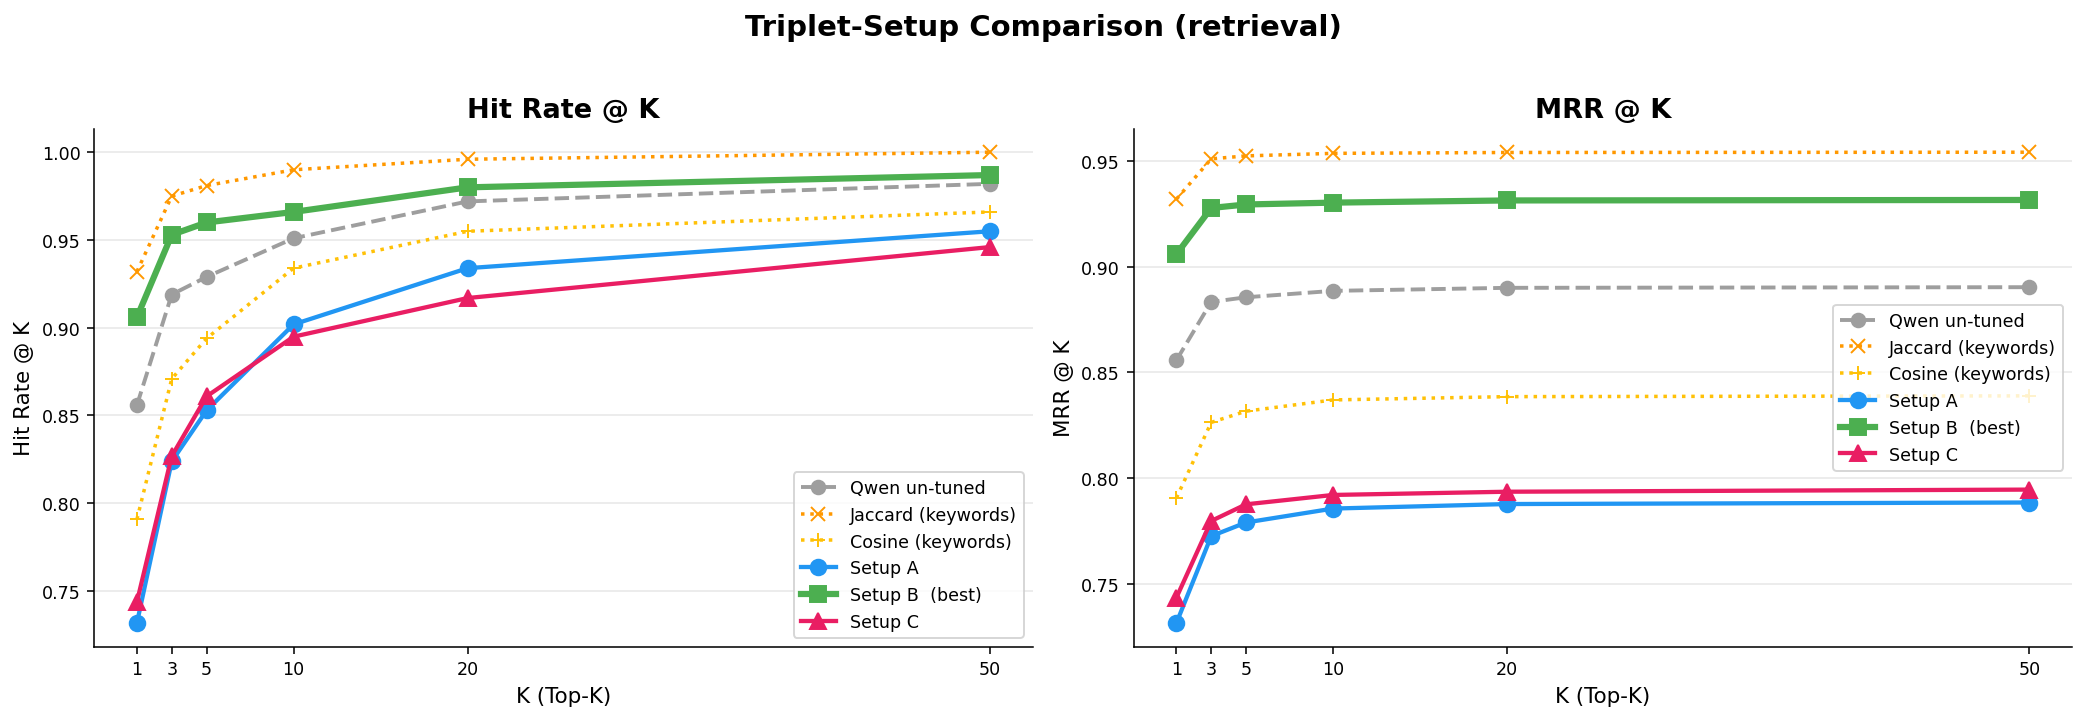

In [19]:
# --- HR@K and MRR@K: setups A/B/C vs un-tuned & keyword references ---
setup_styles = {'A': ('o-', '#2196F3'), 'B': ('s-', '#4CAF50'), 'C': ('^-', '#E91E63')}
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, metric, title in [(axes[0], 'hit_rate', 'Hit Rate @ K'), (axes[1], 'mrr', 'MRR @ K')]:
    ax.plot(K_VALUES, [res_untuned[k][metric] for k in K_VALUES], 'o--', color='#9E9E9E',
            lw=2, ms=7, label='Qwen un-tuned')
    ax.plot(K_VALUES, [res_jaccard[k][metric] for k in K_VALUES], 'x:', color='#FF9800',
            lw=1.8, ms=7, label='Jaccard (keywords)')
    ax.plot(K_VALUES, [res_cosine[k][metric] for k in K_VALUES], '+:', color='#FFC107',
            lw=1.8, ms=7, label='Cosine (keywords)')
    for s in ['A', 'B', 'C']:
        st, c = setup_styles[s]
        lbl = f'Setup {s}' + ('  (best)' if s == best_setup else '')
        lw = 3.2 if s == best_setup else 2.2
        ax.plot(K_VALUES, [res_setups[s][k][metric] for k in K_VALUES], st, color=c,
                lw=lw, ms=8, label=lbl)
    ax.set_xlabel('K (Top-K)'); ax.set_ylabel(title); ax.set_title(title, fontsize=14, weight='bold')
    ax.set_xticks(K_VALUES); ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=9, loc='best')
    sns.despine(ax=ax)
plt.suptitle('Triplet-Setup Comparison (retrieval)', fontsize=15, weight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'setups_hr_mrr.png'), bbox_inches='tight'); plt.show()

## 10. Best setup: full-recipe-list vs sampled training

Re-train the **best** setup on the **entire** ingredient lists (no 40-80% sampling) and compare it head-to-head with the sampled version on the identical test set. Off by default - set `RETRAIN_BEST_FULL = True` in the Control Center to run it.

In [20]:
if not RETRAIN_BEST_FULL:
    print('RETRAIN_BEST_FULL is False -> skipping the full-list vs sampled comparison.')
else:
    FULL_ADAPTER = os.path.join(QWEN_DIR, f'qwen_best_setup_FULL_lora_{VARIANT_TAG}')
    print(f'Best setup = {best_setup}. Training it on FULL ingredient lists (truncate=False)...')
    tok, model = train_setup(best_setup, FULL_ADAPTER, truncate=False)
    full_emb = compute_model_embeddings(model, tok, 'mean', f'best_{best_setup}_fulltrain_mean', recompute=True)
    print(f'\nBest setup {best_setup} trained on FULL lists:')
    res_full = eval_all_K(full_emb)
    del model, tok, full_emb; free_mem()

    res_samp = res_setups[best_setup]
    rows = []
    for k in K_VALUES:
        rows.append({'K': k,
            'Sampled HR':  f'{res_samp[k]["hit_rate"]:.1%}', 'Full HR':  f'{res_full[k]["hit_rate"]:.1%}',
            'Sampled MRR': f'{res_samp[k]["mrr"]:.3f}',       'Full MRR': f'{res_full[k]["mrr"]:.3f}',
            'Sampled Cov': f'{res_samp[k]["coverage"]:.1%}',  'Full Cov': f'{res_full[k]["coverage"]:.1%}'})
    cmp_df = pd.DataFrame(rows)
    print(f'\n=== Setup {best_setup}: sampled (40-80%) vs full-list training ===')
    print(cmp_df.to_string(index=False))
    cmp_df.to_csv(os.path.join(ART_DIR, f'summary_best_full_vs_sampled_{VARIANT_TAG}.csv'), index=False)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for ax, metric, title in [(axes[0], 'hit_rate', 'Hit Rate @ K'), (axes[1], 'mrr', 'MRR @ K')]:
        ax.plot(K_VALUES, [res_samp[k][metric] for k in K_VALUES], 'o-',  color='#2196F3',
                lw=2.5, ms=8, label='Trained on sampled (40-80%)')
        ax.plot(K_VALUES, [res_full[k][metric] for k in K_VALUES], 's--', color='#E91E63',
                lw=2.5, ms=8, label='Trained on FULL lists')
        ax.set_xlabel('K (Top-K)'); ax.set_ylabel(title); ax.set_title(title, fontsize=14, weight='bold')
        ax.set_xticks(K_VALUES); ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=10)
        sns.despine(ax=ax)
    plt.suptitle(f'Best Setup ({best_setup}): Full-List vs Sampled Training', fontsize=15, weight='bold', y=1.02)
    plt.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, 'best_setup_full_vs_sampled.png'), bbox_inches='tight'); plt.show()

RETRAIN_BEST_FULL is False -> skipping the full-list vs sampled comparison.


---
*This notebook caches only the single best-performing setup's adapter under `Data/Qwen_Models/qwen_best_setup_lora_tripletsetups`. Per-setup metrics, base triples, and embeddings are cached under* `Data/Qwen_Models/artifacts/`. *Plots go to* `Modeling/output_plots_triplet_setups/`.